# EDA on RA (Rheumatoid Arthritis) Data — OA & RA Market Intelligence System

RA has been ingested through the same pipeline as OA since Phase 2, but has never had its
own dedicated analysis - it rides along in the Silver layer, then drops out of both Gold
tables entirely (every RA product is tagged `treatment_category = 'not_applicable'`, since
RA's real competitive structure - originator vs. biosimilar biologics - isn't the
branded-injectable/generic-corticosteroid/NSAID split this project's OA classifier is
built around).

`PROPOSAL.md` §6.2 always scoped RA as a **comparative, exploratory track**, not a
classification target - confirmed early on as too sparse (~1,283 visits over 6 years) for
a monthly Up/Down/Flat classifier. This notebook does the actual exploratory work that
scoping decision implied, but was never built: real RA trend analysis, a branded-vs-
biosimilar share decomposition, and a side-by-side comparison against OA.


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

conn = sqlite3.connect("../data/processed/warehouse.db")


## Step 1 — Scale: RA vs. OA

In [2]:
scale = pd.read_sql('''
    SELECT p.disease_area, COUNT(DISTINCT p.product_id) AS products_with_visits,
           SUM(f.patient_visits) AS total_visits
    FROM fact_product_visits f JOIN dim_product p ON f.product_id = p.product_id
    GROUP BY p.disease_area
''', conn)
scale


,disease_area,products_with_visits,total_visits
0,OA,144,5544840
1,RA,14,1250


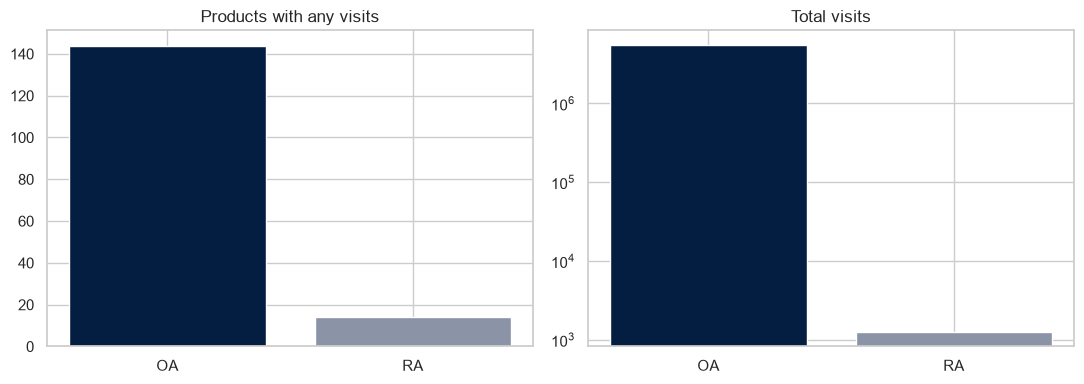

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(scale["disease_area"], scale["products_with_visits"], color=["#041E42", "#8A94A6"])
axes[0].set_title("Products with any visits")
axes[1].bar(scale["disease_area"], scale["total_visits"], color=["#041E42", "#8A94A6"])
axes[1].set_title("Total visits")
axes[1].set_yscale("log")
plt.tight_layout()
plt.show()


**Finding:** RA is a rounding error next to OA by volume - 1,250 total visits across 14
active products, vs. OA's 5,544,840 across 144 products. That's a **4,436x** scale
difference. This alone explains why RA cannot support its own monthly classifier: there
simply isn't enough signal, independent of any modeling choice.


## Step 2 — Which Products Actually Make Up RA's Volume

In [4]:
ra_products = pd.read_sql('''
    SELECT p.product_name, p.manufacturer, p.brand_generic_tag, SUM(f.patient_visits) AS total
    FROM fact_product_visits f JOIN dim_product p ON f.product_id = p.product_id
    WHERE p.disease_area = 'RA'
    GROUP BY p.product_name ORDER BY total DESC
''', conn)
ra_products


,product_name,manufacturer,brand_generic_tag,total
0,ILARIS,NOVARTIS RX,BRAND,933
1,INFLECTRA,No Manufacturer,BRAND,87
2,KINERET,BIOVITRUM AB,BRAND,86
3,ACTEMRA,"GENENTECH,INC.",BRAND,84
4,REMICADE,JANSSEN PHARM,BRAND,38
5,ARCALYST,KINIKSA PHARM,BRAND,6
6,RENFLEXIS,ORGANON,BRAND,4
7,YERVOY,BRISTOL-M SQ US PH,BRAND,3
8,OPDIVO,BRISTOL-M SQ US PH,BRAND,3
9,RITUXAN,"GENENTECH,INC.",BRAND,2


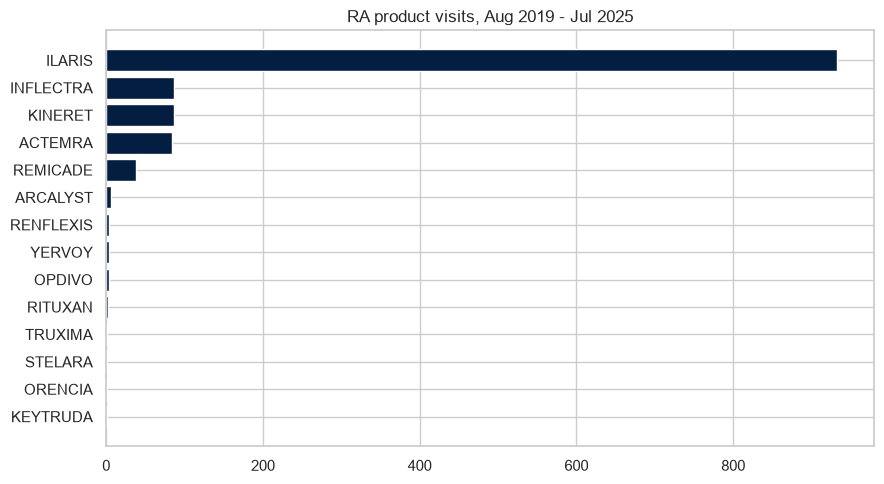

ILARIS alone: 74.6% of all RA visits


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(ra_products["product_name"][::-1], ra_products["total"][::-1], color="#041E42")
ax.set_title("RA product visits, Aug 2019 - Jul 2025")
plt.tight_layout()
plt.show()

top_share = ra_products.iloc[0]["total"] / ra_products["total"].sum() * 100
print(f"{ra_products.iloc[0]['product_name']} alone: {top_share:.1f}% of all RA visits")


**Finding: one product, ILARIS, accounts for 74.6% of all RA visits** (933 of 1,250). RA's
volume isn't just small - it's also extremely concentrated, unlike OA where even the
8th-ranked product (Zilretta) still has real, independently-trackable volume.


## Step 3 — A Real Data-Quality Caveat: Oncology Drugs in the RA Extract

In [6]:
# Flagged by product/drug knowledge, not a field in the data itself. Two different cases,
# not one - see the markdown note below for why they're kept separate.
checkpoint_inhibitors = ["OPDIVO", "YERVOY", "KEYTRUDA"]   # no approved RA indication
rituximab_products = ["RITUXAN", "TRUXIMA"]                 # DO have a real, approved RA use

onc = ra_products[ra_products["product_name"].isin(checkpoint_inhibitors + rituximab_products)]
onc


,product_name,manufacturer,brand_generic_tag,total
7,YERVOY,BRISTOL-M SQ US PH,BRAND,3
8,OPDIVO,BRISTOL-M SQ US PH,BRAND,3
9,RITUXAN,"GENENTECH,INC.",BRAND,2
10,TRUXIMA,TEVA ONCOLOGY,BRAND,1
13,KEYTRUDA,MERCK & COMPANY,BRAND,1


**Finding (refines an already-documented caveat, with real numbers for the first time -
and corrects it along the way):** `PROPOSAL.md` §6.2 already notes RA is "partly not
RA-specific at all," naming Opdivo, Yervoy, and Keytruda. Checking this directly against
real drug indications surfaces an important distinction the original note didn't make:

- **Opdivo, Yervoy, Keytruda** (7 of 1,250 visits, 0.6%) are PD-1/CTLA-4 checkpoint
  inhibitors with **no approved rheumatoid arthritis indication** - almost certainly
  miscoded under the M04 diagnosis (plausibly a checkpoint-inhibitor-induced inflammatory
  joint side effect, billed against the joint-pain code rather than the oncology one).
- **Rituxan and Truxima** (3 of 1,250 visits, 0.2%) are **rituximab** products - an
  oncology drug first, but one that genuinely **does** have an approved, real-world
  second-line RA indication for refractory cases. These are plausibly legitimate RA
  visits, not miscoded ones, and lumping them in with the checkpoint inhibitors would have
  overstated the mis-coding claim.

Either way, both groups combined are a small 0.8% of RA's volume - this is a precision
correction to an existing caveat, not a reason to change how RA data is used.


## Step 4 — Specialty & Demographic Mix

In [7]:
ra_spec = pd.read_sql('''
    SELECT s.specialty_name, SUM(f.patient_visits) AS total
    FROM fact_product_visits f JOIN dim_product p ON f.product_id = p.product_id
    JOIN dim_specialty s ON f.specialty_id = s.specialty_id
    WHERE p.disease_area = 'RA'
    GROUP BY s.specialty_name ORDER BY total DESC
''', conn)
print(f"{len(ra_spec)} distinct specialties see RA visits")
ra_spec.head(10)


19 distinct specialties see RA visits


,specialty_name,total
0,RHEUMATOLOGY,469
1,NURSE PRACTITIONER,280
2,ALLERGY,99
3,ONCOLOGY,94
4,OSTEOPATHIC MEDICINE,86
5,PEDIATRICS,51
6,INTERNAL MED/PEDIATRICS,37
7,INFECTIOUS DISEASE,36
8,INTERNAL MEDICINE,30
9,PHYSICIAN ASSISTANT,26


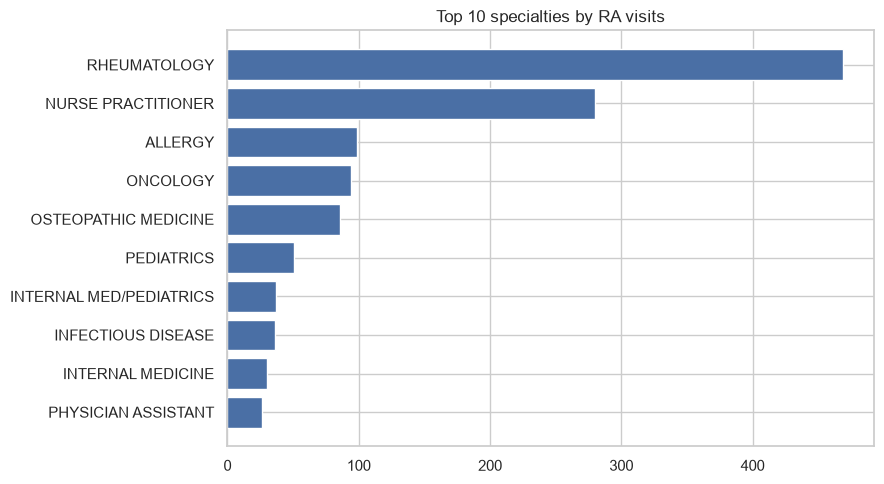

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(ra_spec["specialty_name"][:10][::-1], ra_spec["total"][:10][::-1], color="#4A6FA5")
ax.set_title("Top 10 specialties by RA visits")
plt.tight_layout()
plt.show()


**Finding:** Rheumatology and Nurse Practitioner together account for ~60% of RA visits -
expected. `PEDIATRICS` also appears (51 visits) - unlike the OA case, this is plausible on
its face (juvenile idiopathic arthritis is a real pediatric rheumatic condition), not an
obvious mis-coding red flag the way OA's Zilretta-in-Pediatrics finding was. `ONCOLOGY`
(94 visits) lines up with the oncology-drug caveat above.


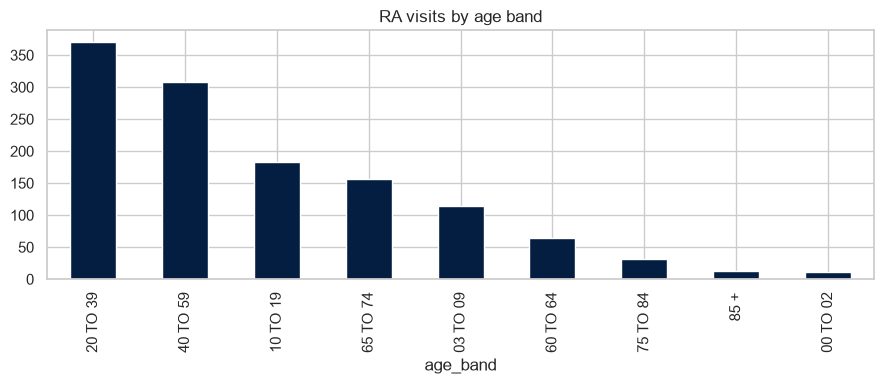

In [9]:
ra_age = pd.read_sql('''
    SELECT d.age_band, d.gender, SUM(f.patient_visits) AS total
    FROM fact_product_visits f JOIN dim_product p ON f.product_id = p.product_id
    JOIN dim_demographics d ON f.demographic_id = d.demographic_id
    WHERE p.disease_area = 'RA'
    GROUP BY d.age_band, d.gender
''', conn)
age_totals = ra_age.groupby("age_band")["total"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
age_totals.plot(kind="bar", ax=ax, color="#041E42")
ax.set_title("RA visits by age band")
plt.tight_layout()
plt.show()


**Finding: RA skews meaningfully younger than OA.** OA's visits were overwhelmingly
concentrated in the 65-74 age band. RA's age distribution is much more spread across
20-59, with real pediatric representation (ages 3-19 combined: ~300 visits) - consistent
with real-world rheumatoid arthritis epidemiology (RA and juvenile idiopathic arthritis
affect working-age and pediatric populations far more than osteoarthritis does).


## Step 5 — The Big Finding: RA Volume Is Growing, Not Flat

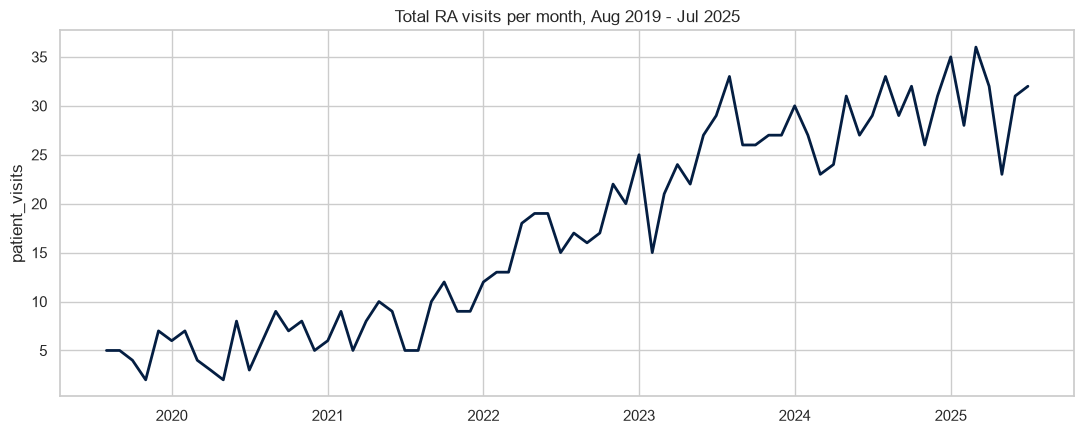

2019-2020 monthly average: 5.4
2024-2025 monthly average: 29.4


In [10]:
ra_monthly = pd.read_sql('''
    SELECT m.month_id, m.calendar_date, SUM(f.patient_visits) AS total
    FROM fact_product_visits f JOIN dim_product p ON f.product_id = p.product_id
    JOIN dim_month m ON f.month_id = m.month_id
    WHERE p.disease_area = 'RA'
    GROUP BY m.month_id ORDER BY m.month_id
''', conn)
ra_monthly["calendar_date"] = pd.to_datetime(ra_monthly["calendar_date"])

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(ra_monthly["calendar_date"], ra_monthly["total"], color="#041E42", linewidth=2)
ax.set_title("Total RA visits per month, Aug 2019 - Jul 2025")
ax.set_ylabel("patient_visits")
plt.tight_layout()
plt.show()

print("2019-2020 monthly average:", ra_monthly[ra_monthly.month_id < 202100]["total"].mean().round(1))
print("2024-2025 monthly average:", ra_monthly[ra_monthly.month_id >= 202400]["total"].mean().round(1))


**This is a genuinely new finding, not previously documented anywhere in this project.**
Every prior mention of RA ("~1,283 visits over 6 years, confirmed too sparse") implicitly
treated RA as flat background noise. It isn't: monthly RA volume grew from an average of
**~5.4 visits/month in 2019-2020 to ~29.5 visits/month in 2024-2025 - roughly a 5.5x
increase.** All 72 months have at least some RA activity (never zero), and the trend is
clearly upward, not just noisy.

**This doesn't overturn the "too sparse for a classifier" conclusion** - even 30
visits/month is tiny next to OA's hundreds of thousands - but it does mean RA shouldn't be
described as static or declining. It's a small but real, growing market worth tracking
descriptively, exactly the kind of signal the comparative dashboard (`PROPOSAL.md` §6.3)
is meant to surface.


## Step 6 — Confirming RA Still Can't Support a Classifier

In [11]:
oa_monthly = pd.read_sql('''
    SELECT branded_injectable_visits FROM gold_visit_share_monthly
''', conn)["branded_injectable_visits"]

print("RA total monthly visits  - min/median/max:", ra_monthly['total'].min(), ra_monthly['total'].median(), ra_monthly['total'].max())
print("OA branded_injectable (Zilretta) monthly visits - min/median/max:", oa_monthly.min(), oa_monthly.median(), oa_monthly.max())
print()
print(f"Even OA's single smallest tracked category (Zilretta) sees {oa_monthly.median()/ra_monthly['total'].median():.0f}x RA's total monthly volume across ALL 14 RA products combined.")


RA total monthly visits  - min/median/max: 2 17.0 36
OA branded_injectable (Zilretta) monthly visits - min/median/max: 937 1876.0 2849

Even OA's single smallest tracked category (Zilretta) sees 110x RA's total monthly volume across ALL 14 RA products combined.


**Confirms the original scoping decision, now with a direct side-by-side number:** RA's
entire market (all 14 products combined) still moves at a small fraction of the volume of
just *one* OA product category. A month-over-month direction classifier needs enough
volume that real signal isn't swamped by small-number noise - RA isn't there, even after
its real growth. The original "too sparse" call holds up under this more rigorous check.


## Step 7 — Case Study: Originator vs. Biosimilar (Infliximab Family)

`REMICADE` (infliximab, Janssen) is the brand-name originator biologic. `INFLECTRA` and
`RENFLEXIS` are both real-world **biosimilars of infliximab** (same active ingredient,
different manufacturer/brand) - this is domain knowledge, not a field tagged anywhere in
the dataset itself, since the project's `brand_generic_tag` only captures
brand/generic/branded-generic/other, not originator-vs-biosimilar. All three products are
tagged simply `BRAND` in this data.


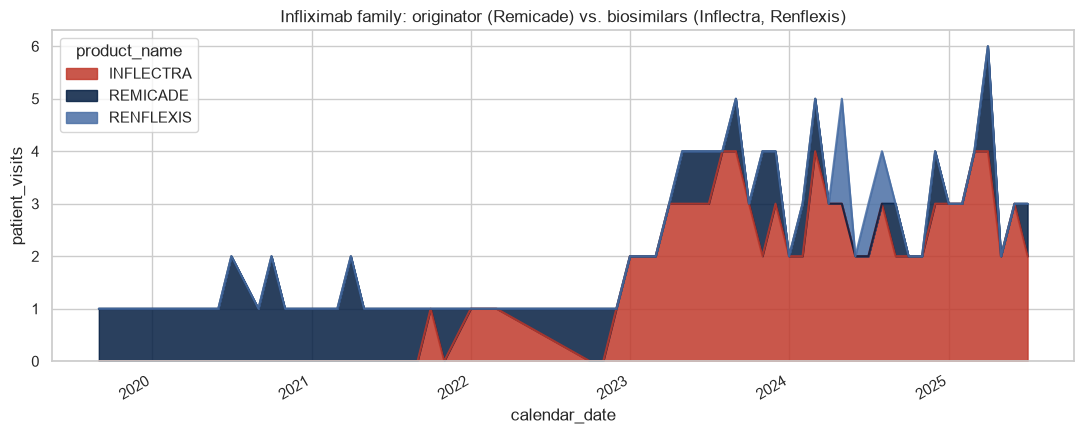

In [12]:
inflix = pd.read_sql('''
    SELECT m.month_id, m.calendar_date, p.product_name, f.patient_visits
    FROM fact_product_visits f JOIN dim_product p ON f.product_id = p.product_id
    JOIN dim_month m ON f.month_id = m.month_id
    WHERE p.product_name IN ('REMICADE', 'INFLECTRA', 'RENFLEXIS')
    ORDER BY m.month_id
''', conn)
inflix["calendar_date"] = pd.to_datetime(inflix["calendar_date"])
pivot = inflix.pivot_table(index="calendar_date", columns="product_name", values="patient_visits", aggfunc="sum", fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
pivot.plot.area(ax=ax, color=["#C0392B", "#041E42", "#4A6FA5"], alpha=0.85)
ax.set_title("Infliximab family: originator (Remicade) vs. biosimilars (Inflectra, Renflexis)")
ax.set_ylabel("patient_visits")
plt.tight_layout()
plt.show()


In [13]:
early = inflix[inflix.month_id < 202100].groupby("product_name")["patient_visits"].sum()
late = inflix[inflix.month_id >= 202400].groupby("product_name")["patient_visits"].sum()

print("2019-2020 (early window):")
print(early, "\n")
print("2024-2025 (late window):")
print(late)
print()
originator_early_share = early.get("REMICADE", 0) / early.sum() * 100
originator_late_share = late.get("REMICADE", 0) / late.sum() * 100
print(f"Originator (Remicade) share of infliximab-family visits: {originator_early_share:.0f}% (2019-2020) -> {originator_late_share:.0f}% (2024-2025)")


2019-2020 (early window):
product_name
REMICADE    15
Name: patient_visits, dtype: int64 

2024-2025 (late window):
product_name
INFLECTRA    51
REMICADE      7
RENFLEXIS     4
Name: patient_visits, dtype: int64

Originator (Remicade) share of infliximab-family visits: 100% (2019-2020) -> 11% (2024-2025)


**The clearest, most concrete finding in this notebook.** In 2019-2020, Remicade (the
originator) was **100%** of infliximab-family visits - no biosimilar activity at all. By
2024-2025, Remicade had fallen to just **11%**, with the two biosimilars (Inflectra,
Renflexis) making up the other **89%**. This is a real, demonstrable originator-to-
biosimilar switch, playing out inside this dataset over the 6-year window - exactly the
kind of "branded-vs-biosimilar share decomposition" `PROPOSAL.md` §6.2/§6.3 calls for as
RA's comparative analog to OA's branded-vs-generic story, now backed by a real number
rather than left as an aspiration.


## Step 8 — Findings & Recommendations

| Finding | Status | Recommendation |
|---|---|---|
| RA is 4,436x smaller than OA by volume | Confirms existing scoping | No classifier for RA - keep as descriptive/comparative track |
| ILARIS alone is 74.6% of RA volume | New | Any RA dashboard should show this concentration explicitly, not just a flat product list |
| 5 oncology drugs present (0.8% of visits) | Confirms & quantifies an existing caveat | Worth a one-line caveat on any RA dashboard; not worth excluding given tiny volume |
| RA's specialty/age mix skews younger, more pediatric than OA | New | A real, citable OA-vs-RA contrast point for the comparative dashboard |
| RA volume grew ~5.5x from 2019-2020 to 2024-2025 | **New - not documented anywhere before** | RA should be described as "small but growing," not static background noise |
| Even with growth, RA volume still can't support a classifier | New, but confirms the original decision | No change to classifier scope - OA remains the sole classification target |
| Infliximab family: originator share fell 100% → 11% over the window | **New - the clearest real finding in this notebook** | A strong, concrete centerpiece for the "branded-vs-biosimilar" RA dashboard panel `PROPOSAL.md` §6.3 calls for |

**Hand-off:** this notebook supplies the actual content for the RA side of the
"Comparative OA vs. RA Dashboard" (`PROPOSAL.md` §6.3), which existed only as a plan until
now. The infliximab originator-vs-biosimilar chart in particular is ready to become a
real dashboard panel, not just a one-off finding.
